# Moby GRPC Client

In [1]:
from interfaces.moby_client import MobyClient
from interfaces.ethercat_client import EtherCATClient
import time

ip = '192.168.214.20'
moby = MobyClient(ip)
ecat = EtherCATClient(ip)

## Check System

In [2]:
print("Master status: ", ecat.get_master_status())
print("RxDomain status: ", ecat.get_rxdomain_status())
print("TxDomain status: ", ecat.get_txdomain_status())
print("Slave status: ", ecat.get_slave_status())
print("Is System Ready: ", ecat.is_system_ready())
print("Is Servo On: ", ecat.is_servo_on())

Master status:  OP
RxDomain status:  COMPLETE
TxDomain status:  COMPLETE
Slave status:  ['OP', 'OP', 'OP', 'OP', 'OP', 'OP', 'OP', 'OP', 'OP', 'OP']
Is System Ready:  [True, True, True, True, True, True, True, True]
Is Servo On:  [True, True, True, True, True, True, True, True]


In [3]:
rot_tx = []
rot_tx.append(ecat.get_servo_tx(0))
rot_tx.append(ecat.get_servo_tx(2))
rot_tx.append(ecat.get_servo_tx(4))
rot_tx.append(ecat.get_servo_tx(6))

whl_tx = []
whl_tx.append(ecat.get_servo_tx(1))
whl_tx.append(ecat.get_servo_tx(3))
whl_tx.append(ecat.get_servo_tx(5))
whl_tx.append(ecat.get_servo_tx(7))

print("Rotation motor")
for i in range(0, 4):
    print(rot_tx[i], (rot_tx[i][0]), (rot_tx[i][1], rot_tx[i][0]))
    
print("Wheel motor")
for i in range(0, 4):
    print(whl_tx[i], (whl_tx[i][0]), (whl_tx[i][1], whl_tx[i][0]))
    
rot_rx = []
rot_rx.append(ecat.get_servo_rx(0))
rot_rx.append(ecat.get_servo_rx(2))
rot_rx.append(ecat.get_servo_rx(4))
rot_rx.append(ecat.get_servo_rx(6))

whl_rx = []
whl_rx.append(ecat.get_servo_rx(1))
whl_rx.append(ecat.get_servo_rx(3))
whl_rx.append(ecat.get_servo_rx(5))
whl_rx.append(ecat.get_servo_rx(7))

print("Rotation motor")
for i in range(0, 4):
    print(rot_rx[i])
    
print("Wheel motor")
for i in range(0, 4):
    print(whl_rx[i])

Rotation motor
['OPERATION_ENABLED', 'CST', 309679625, -18000, 0] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
['OPERATION_ENABLED', 'CST', 138175777, -18000, 0] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
['OPERATION_ENABLED', 'CST', -265761780, -4000, 0] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
['OPERATION_ENABLED', 'CST', 174046640, 3500, 0] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
Wheel motor
['OPERATION_ENABLED', 'CST', -8, 0, 0] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
['OPERATION_ENABLED', 'CST', -152, 0, 0] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
['OPERATION_ENABLED', 'CST', 10, 0, -1] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
['OPERATION_ENABLED', 'CST', 12, 0, 0] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
Rotation motor
[15, 10, 0, 0, 0]
[15, 10, 0, 0, 0]
[15, 10, 0, 0, 0]
[15, 10, 0, 0, 0]
Wheel motor
[15, 10, 0, 0, 0]
[15, 10, 0, 0, 0]
[15, 10, 0, 0, 0]
[15, 10, 0, 0, 0]


In [8]:
# ecat.set_servo(servo_idx=0, on=True)
ecat.set_servo(servo_idx=1, on=False)

## Get Moby State

get state
- STRING STATE
    - status : current moby state

- BOOL STATE
    - is_ready : ethercat connected and master&slaves operational
    - is_enable : all wheel servo on
    - is_moving : move state
    - is_violation : violation

In [12]:
moby.get_moby_state()

{'state': 'VIOLATE',
 'is_ready': True,
 'is_enable': True,
 'is_moving': False,
 'is_violation': True}

get [error state, wheel num, none, none]

In [13]:
print(moby.get_moby_error_state())

['SW_BUMPER_DETECT', 0, 0, 0]


recover error state

In [11]:
ecat.set_servo(servo_idx=1, on=False)

In [27]:
moby.recover()

In [13]:
# moby.set_extra_do([True, True, True, True, True, True, True, True])
moby.set_extra_do([False, False, False, False, False, False, False, False])

In [82]:
ecat.get_ioboard_rx()

{'do5v': 0, 'do24v1': 1, 'do24v2': 0, 'ao1': 0, 'ao2': 0, 'ft_param': 0}

In [11]:
ecat.get_ioboard_tx()

{'di5v': 0, 'di24v1': 0, 'di24v2': 1, 'ai1': 0, 'ai2': 0}

## Get BMS Data

In [16]:
moby.get_bms()

{'BMS status-1': 83.0,
 'BMS status-2': 86.6,
 'Pack voltage-1': 54.62,
 'Pack voltage-2': 54.62,
 'Battery Voltage-1': 54.54,
 'Battery Voltage-2': 54.56,
 'Pack current1-1': -0.2,
 'Pack current1-2': 0.0,
 'Pack current2-1': -3.0,
 'Pack current2-2': -3.6,
 'Is Charge': 0,
 'Is Cell OverVoltage': 0,
 'Is Cell UnderVoltage': 0,
 'Is OverCurrent Charge': 0,
 'Is OverCurrent Discharge': 0,
 'Is Short Circuit': 0,
 'Is OverTemperature': 0,
 'Is Pack OverVoltage': 0,
 'SOC': 0.0,
 'SOH': 0,
 'Time for Charge': 0,
 'time for Discharge': 0,
 'Remain Capacity Ah': 0.0,
 'Remain Capacity Wh': 0,
 'Temperature-1': 29.0,
 'Temperature-2': 30.0,
 'Temperature-3': 33.0,
 'Temperature-4': 33.0,
 'Cell Voltage-1': 0.0,
 'Cell Voltage-2': 0.0,
 'Cell Voltage-3': 0.0,
 'Cell Voltage-4': 0.0,
 'Cell Voltage-5': 0.0,
 'Cell Voltage-6': 0.0,
 'Cell Voltage-7': 0.0,
 'Cell Voltage-8': 0.0,
 'Cell Voltage-9': 0.0,
 'Cell Voltage-10': 0.0,
 'Cell Voltage-11': 0.0,
 'Cell Voltage-12': 0.0,
 'Cell Voltage-13

## Get Moby's pose related

In [17]:
print("Pose [Px, Py, Pw]", [format(p, '.3f') for p in moby.get_moby_pose()])

print("Vel [Px, Py, Pw]", [format(v, '.3f') for v in moby.get_moby_vel()])

rot = moby.get_rotation_angle()
print("Rotation angle (deg)", [format(rot['fl'], '.3f'), format(rot['fr'], '.3f'), format(rot['bl'], '.3f'), format(rot['br'], '.3f')])

drv = moby.get_drive_speed()
print("Driving speed (m/s)", [format(drv['fl'], '.3f'), format(drv['fr'], '.3f'), format(drv['bl'], '.3f'), format(drv['br'], '.3f')])


Pose [Px, Py, Pw] ['-7.115', '-29.033', '-4.375']
Vel [Px, Py, Pw] ['0.182', '0.019', '0.018']
Rotation angle (deg) ['-15.348', '178.679', '-3.634', '176.113']
Driving speed (m/s) ['0.182', '-0.174', '0.190', '-0.158']


## Gyro data

In [18]:
print("Gyro [yaw, yaw_rate]", moby.get_gyro_data())

Gyro [yaw, yaw_rate] [0.0, 0.0]


In [19]:
print(moby.get_imu_data())

([0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0])


In [20]:
moby.use_gyro_for_odom(False)

In [21]:
moby.reset_gyro()

## Set Param

### set rotation motor zero as current pose

In [ ]:
moby.set_zero_as_current()

### set rotation interpolator
0: Ramp interpolator  　　　　  1: Streaming interpolator

2: Velocity interpolator   　　　 3: Trapezoidal interpolator

In [23]:
moby.set_rotation_interpolator(val=0)

### set rotation controller type

0: HINFPID_CONTROLLER

1: SIMPLEPID_POS_CONTROLLER

2: SIMPLEPID_VEL_CONTROLLER

In [24]:
moby.set_rotation_controller_type(val=0)

### set rotation vel acc
- vel
- acc

In [25]:
moby.set_rotation_vel_acc(vel=1.380, acc=400.0)
# moby.set_rotation_vel_acc(vel=1.8849, acc=942.0)

### set drive interpolator on/off

In [26]:
moby.set_drive_interpolator_on_off(on=True)

### set drive acc dec
- acc
- dec

In [27]:
moby.set_drive_acc_dec(acc = 0.01, dec = 0.01)


### set Moby Rotation Motor Gain
index : front left:0,　 frong right:1,　 back left:2,　 back right:3

In [28]:
moby.set_rotation_gain(index=0, k=3500, kv=1300, kp=100)
moby.set_rotation_gain(index=1, k=3500, kv=1300, kp=100)
moby.set_rotation_gain(index=2, k=3500, kv=1300, kp=100)
moby.set_rotation_gain(index=3, k=3500, kv=1300, kp=100)

In [29]:
print(moby.get_rotation_gain(index=0))

{'k': 3500.0, 'kv': 1300.0, 'kp': 100.0}


In [30]:
# moby.set_kinematics_forced(True, 10)
moby.set_kinematics_forced(False, 10)

In [38]:
print(moby.get_kinematics_forced())


(False, 10)


## Rotation, Driving Move control

### get rotation angle, driving speed, robot velocity

In [32]:
rot = moby.get_rotation_angle()
print("Rotation angle (deg)", [format(rot["fl"], '.3f'), format(rot["fr"], '.3f'), format(rot["bl"], '.3f'), format(rot["br"], '.3f')])

drv = moby.get_drive_speed()
print("drive speed (m/s)", [format(drv["fl"], '.3f'), format(drv["fr"], '.3f'), format(drv["bl"], '.3f'), format(drv["br"], '.3f')])

body = moby.get_target_vel()
print("moby velocity (m/s)", [format(body[0], '.3f'), format(body[1], '.3f'), format(body[2], '.3f')])

Rotation angle (deg) ['-1162.797', '0.001', '-0.002', '0.004']
drive speed (m/s) ['0.000', '0.000', '0.000', '0.000']
moby velocity (m/s) ['0.000', '0.000', '0.000']


go straight -> move rotation to zero deg

In [33]:
moby.go_straight()

In [34]:
moby.stop_motion()

### set rotation angle of each wheel(deg)

In [46]:
fl = 0
fr = 0
bl = 0
br = 0

# fl = 90
# fr = 90
# bl = 90
# br = 90

moby.move_rotation_deg(fl=fl, fr=fr, bl=bl, br=br)

In [55]:
moby.stop_motion()

### set driving speed of each wheel(m/s)

In [37]:
fl = 0.1
fr = 0.1
bl = 0.1
br = 0.1
moby.move_driving_mps(fl=fl, fr=fr, bl=bl, br=br)

In [38]:
moby.stop_motion()

### set velocity of moby(m/s)

In [39]:
moby.set_target_vel(vx=0.2, vy=0.0 ,vw=0.0)

In [45]:
moby.stop_motion()

## Keyboard control

install python module
- pip install keyboard
- pip install ipython

|　|(8:+vx)|　|
|:------:|:---:|:---:|
|**(4:+vy)**|**(5:-vx)**|**(6:-vy)**|
|**(1:-vw)**|　|**(3:+vw)**|

**(7:stop)**

**(q:quit)**

In [56]:
import keyboard
import time
from IPython.display import clear_output

vel_x = 0
vel_y = 0
vel_w = 0
vel_interval = 0.05

print("[vx, vy, vw]")
while True:
    clear_output(wait=True)
    time.sleep(0.1)
#     time.sleep(0.01)
    key = keyboard.read_key()
    if key == "q":
        print("q")
        break
    else:
        if key=="4":
            vel_y += vel_interval
        elif key=="6":
            vel_y -= vel_interval
        elif key=="8":
            vel_x += vel_interval
        elif key=="5":
            vel_x -= vel_interval
        elif key=="3":
            vel_w += vel_interval
        elif key=="1":
            vel_w -= vel_interval
        elif key=="7":
            vel_x = 0
            vel_y = 0
            vel_w = 0
        print("[{:.6f}, {:.6f}, {:.6f}]".format(vel_x,vel_y,vel_w))
        moby.set_target_vel(vel_x, vel_y, vel_w)
        key = False

q


In [11]:
moby.stop_motion()

## For Agri


In [265]:
print("Master status: ", ecat.get_master_status())
print("RxDomain status: ", ecat.get_rxdomain_status())
print("TxDomain status: ", ecat.get_txdomain_status())
print("Slave status: ", ecat.get_slave_status())
print("Is System Ready: ", ecat.is_system_ready())
print("Is Servo On: ", ecat.is_servo_on())

Master status:  OP
RxDomain status:  COMPLETE
TxDomain status:  COMPLETE
Slave status:  ['OP', 'OP', 'OP', 'OP', 'OP']
Is System Ready:  [False, True, False, False]
Is Servo On:  [True, True, True, True]


In [100]:
rot_tx = []
rot_tx.append(ecat.get_servo_tx(0))
rot_tx.append(ecat.get_servo_tx(1))

whl_tx = []
whl_tx.append(ecat.get_servo_tx(2))
whl_tx.append(ecat.get_servo_tx(3))

print("Rotation motor")
for i in range(0, 2):
    print(rot_tx[i], (rot_tx[i][0]), (rot_tx[i][1], rot_tx[i][0]))
    
print("Wheel motor")
for i in range(0, 2):
    print(whl_tx[i], (whl_tx[i][0]), (whl_tx[i][1], whl_tx[i][0]))
    
rot_rx = []
rot_rx.append(ecat.get_servo_rx(0))
rot_rx.append(ecat.get_servo_rx(1))

whl_rx = []
whl_rx.append(ecat.get_servo_rx(2))
whl_rx.append(ecat.get_servo_rx(3))

print("Rotation motor")
for i in range(0, 2):
    print(rot_rx[i])
    
print("Wheel motor")
for i in range(0, 2):
    print(whl_rx[i])
    

Rotation motor
['FAULT', 'CST', 0, 0, 0] FAULT ('CST', 'FAULT')
['FAULT', 'CST', 0, 0, -1] FAULT ('CST', 'FAULT')
Wheel motor
['SWITCH_DISABLED', 'PP', -576802695, 0, 0] SWITCH_DISABLED ('PP', 'SWITCH_DISABLED')
['OPERATION_ENABLED', 'CST', 382624875, 0, 0] OPERATION_ENABLED ('CST', 'OPERATION_ENABLED')
Rotation motor
[15, 10, 0, 0, 0]
[15, 10, 0, 0, 0]
Wheel motor
[47, 1, -576805512, 0, 0]
[15, 10, 0, 0, 0]


In [285]:
moby.get_moby_state()

{'state': 'MOVING',
 'is_ready': True,
 'is_enable': True,
 'is_moving': True,
 'is_violation': False}

In [286]:
print(moby.get_moby_error_state())

['NONE', 0, 0, 0]


In [ ]:
ecat.set_servo(servo_idx=1, on=False)

In [14]:
moby.recover()

In [53]:
ecat.set_servo_rx(0, 15, 0x0a, 0, 0, 0)
ecat.set_servo_rx(1, 15, 0x0a, 0, 0, 0)
ecat.set_servo_rx(2, 15, 0x0a, 0, 0, 0)
ecat.set_servo_rx(3, 15, 0x0a, 0, 0, 0)

0 15 10 0 0 0
1 15 10 0 0 0
2 15 10 0 0 0
3 15 10 0 0 0


## Control CamRobot init 

In [7]:
rotation_deg2cnt = 1165084
rotation_cnt2deg = 1/rotation_deg2cnt

elevation_cm2cnt = 13981013
elevation_cnt2cm = 1/elevation_cm2cnt

def rotation_move_by(target_pos_deg, sync_mode=False):    
    ecat_data = ecat.get_servo_tx(2)
    
    repeat_data = ecat_data[1]
    curr_pos_cnt = ecat_data[2]
    target_pos_cnt = int(target_pos_deg*rotation_deg2cnt + curr_pos_cnt)
    
    repeat = 1
    if repeat_data != 1:
        repeat = 2
    
    for i in range(0, repeat):
        if sync_mode:
            ecat.set_servo_rx(2, 0x1f, 1, target_pos_cnt, 0, 0)
        else:
            ecat.set_servo_rx(2, 0x3f, 1, target_pos_cnt, 0, 0)
            time.sleep(0.01)
            ecat.set_servo_rx(2, 0x2f, 1, target_pos_cnt, 0, 0)
        
def elevator_move_by(target_pos_cm, sync_mode=False):
    ecat_data = ecat.get_servo_tx(3)
    
    repeat_data = ecat_data[1]
    curr_pos_cnt = ecat_data[2]
    
    target_pos_cnt = int(target_pos_cm*elevation_cm2cnt + curr_pos_cnt)
    repeat = 1
    if repeat_data != 1:
        repeat = 2
    
    for i in range(0, repeat):
        if sync_mode:
            ecat.set_servo_rx(3, 0x1f, 1, target_pos_cnt, 0, 0)
        else:
            ecat.set_servo_rx(3, 0x3f, 1, target_pos_cnt, 0, 0)
            time.sleep(0.01)
            ecat.set_servo_rx(3, 0x2f, 1, target_pos_cnt, 0, 0)
        
def robot_torque_zero():    
    ecat.set_servo_rx(2, 15, 0x0a, 0, 0, 0)
    ecat.set_servo_rx(3, 15, 0x0a, 0, 0, 0)
    
def get_rotation_pos_deg():
    curr_pos_cnt = ecat.get_servo_tx(2)[2]-ecat.get_robot_zero_count(2).count
    return (curr_pos_cnt)*rotation_cnt2deg

def get_elevator_pos_cm():
    curr_pos_cnt = ecat.get_servo_tx(3)[2]-ecat.get_robot_zero_count(3).count
    return (curr_pos_cnt)*elevation_cnt2cm

### set elevator relative move (cm)

In [70]:
elevator_move_by(1)

3 63 1 27248973 0 0
3 47 1 27248973 0 0
3 63 1 27248973 0 0
3 47 1 27248973 0 0


In [74]:
get_elevator_pos_cm()

-1.001358056100799e-06

### set rotation relative move (deg)

In [77]:
rotation_move_by(7)

2 63 1 -278798046 0 0
2 47 1 -278798046 0 0
2 63 1 -278798046 0 0
2 47 1 -278798046 0 0


In [73]:
get_rotation_pos_deg()

3.4332288487353703e-06

In [76]:
robot_torque_zero()

2 15 10 0 0 0
3 15 10 0 0 0


In [12]:
ecat.set_profileVel(3, 400)

In [11]:
ecat.get_profileVel(3)

116

### Agri IO Control

In [7]:
moby.turn_light(True)
moby.turn_light(False)

In [79]:
moby.turn_buzzer(True)
moby.turn_buzzer(False)

In [ ]:
moby.pause_bumper(True)
# moby.pause_bumper(False)

In [ ]:
moby.recover()

### get/set Agri Cam Robot zero position

In [81]:
ecat.get_robot_zero_count(servo_idx=3)

count: 25004800

In [72]:
ecat.set_robot_zero_as_current(servo_idx=2)

## Realtime Logger for swerving moby

dir : ~/release/IndyDeployment/MobyRTLog

q : angle

- 0 : record time

rotation motor (fl, fr, bl, br)

- 1, 2, 3, 4 (q)

- 5, 6, 7, 8 (qdot)

- 9, 10, 11, 12 (tau)

- 13, 14, 15, 16 (target q)



- 17, 18, 19, 20 (q_desired)

- 21, 22, 23, 24 (qdot_desired)

- 25, 26, 27, 28 (qddot_desired)



driving wheel (fl, fr, bl, br)

- 29, 30, 31, 32 (qdot)

- 33, 34, 35, 36 (target qdot)


In [ ]:
moby.start_rt_logging()

In [ ]:
moby.end_rt_logging()

## Moby Test
### - Get Performance Data

In [ ]:
ecat.set_servo(0, True)
ecat.set_servo(2, True)
ecat.set_servo(4, True)
ecat.set_servo(6, True)

In [ ]:
moby.get_moby_state()

{'state': 'IDLE',
 'is_ready': True,
 'is_enable': True,
 'is_moving': False,
 'is_violation': False}

In [134]:
data_file = open("result_data_str.csv", "w")
data_file.write("time[s],tx_rot1:pos,tx_rot2:pos,tx_rot3:pos,tx_rot4:pos,")
data_file.write("tx_rot1:vel,tx_rot2:vel,tx_rot3:vel,tx_rot4:vel,")
data_file.write("tx_rot1:torq,tx_rot2:torq,tx_rot3:torq,tx_rot4:torq\n")

# ecat.set_servo_rx(0, 15, 0x0a, 0, 0, 0)
# ecat.set_servo_rx(2, 15, 0x0a, 0, 0, 0)
# ecat.set_servo_rx(4, 15, 0x0a, 0, 0, 0)
# ecat.set_servo_rx(6, 15, 0x0a, 0, 0, 0)

moby.move_rotation_deg(fl=180, fr=180, bl=180, br=180)

zero_cnt = [ecat.get_servo_tx(0)[2], ecat.get_servo_tx(2)[2], ecat.get_servo_tx(4)[2], ecat.get_servo_tx(6)[2]]
init_time = time.time()

for i in range(300):
    rot_tx = []
    rot_tx.append(ecat.get_servo_tx(0))
    rot_tx.append(ecat.get_servo_tx(2))
    rot_tx.append(ecat.get_servo_tx(4))
    rot_tx.append(ecat.get_servo_tx(6))
    now_time = time.time() - init_time
    data_file.write(f"{now_time}, ")
    data_file.write(f"{(rot_tx[0][2]-zero_cnt[0])*360/847249408}, {(rot_tx[1][2]-zero_cnt[1])*360/847249408}, {(rot_tx[2][2]-zero_cnt[2])*360/847249408}, {(rot_tx[3][2]-zero_cnt[3])*360/847249408}, ")
    data_file.write(f"{rot_tx[0][3]*360/847249408}, {rot_tx[1][3]*360/847249408}, {rot_tx[2][3]*360/847249408}, {rot_tx[3][3]*360/847249408}, ")
    data_file.write(f"{rot_tx[0][4]}, {rot_tx[1][4]}, {rot_tx[2][4]}, {rot_tx[3][4]}\n")
    time.sleep(0.005)

data_file.close()

moby.move_rotation_deg(fl=0, fr=0, bl=0, br=0)

In [ ]:
data_file = open(f"result_data_vx5.csv", "w")
data_file.write("time[s],tx_whl1:vel[m/s],tx_whl2:vel[m/s],tx_whl3:vel[m/s],tx_whl4:vel[m/s],")
data_file.write("tx_whl1:torq[N*m],tx_whl2:torq[N*m],tx_whl3:torq[N*m],tx_whl4:torq[N*m],")
data_file.write("rx_whl1:vel[m/s],rx_whl2:vel[m/s],rx_whl3:vel[m/s],rx_whl4:vel[m/s]\n")

moby.stop_motion()
moby.set_target_vel(vx=0.5, vy=0.0 ,vw=0.0)
init_time = time.time()

now_time = []
whl_tx1 = []
whl_tx2 = []
whl_tx3 = []
whl_tx4 = []
whl_rx1 = []
whl_rx2 = []
whl_rx3 = []
whl_rx4 = []

for i in range(150):
    whl_tx1.append(ecat.get_servo_tx(1))
    whl_tx2.append(ecat.get_servo_tx(3))
    whl_tx3.append(ecat.get_servo_tx(5))
    whl_tx4.append(ecat.get_servo_tx(7))
    whl_rx1.append(ecat.get_servo_rx(1))
    whl_rx2.append(ecat.get_servo_rx(3))
    whl_rx3.append(ecat.get_servo_rx(5))
    whl_rx4.append(ecat.get_servo_rx(7))
    now_time.append(time.time() - init_time)
    time.sleep(0.005)

moby.stop_motion()

for j in range(150):
    data_file.write(f"{now_time[j]},")
    data_file.write(f"{-whl_tx1[j][3]*0.103*(6.283/16384.0)},{-whl_tx2[j][3]*0.103*(6.283/16384.0)},{whl_tx3[j][3]*0.103*(6.283/16384.0)},{whl_tx4[j][3]*0.103*(6.283/16384.0)},")
    data_file.write(f"{-whl_tx1[j][4]*0.008},{-whl_tx2[j][4]*0.008},{whl_tx3[j][4]*0.008},{whl_tx4[j][4]*0.008},")
    data_file.write(f"{-whl_rx1[j][3]*0.103*(6.283/16384.0)},{-whl_rx2[j][3]*0.103*(6.283/16384.0)},{whl_rx3[j][3]*0.103*(6.283/16384.0)},{whl_rx4[j][3]*0.103*(6.283/16384.0)}\n")
    
data_file.close()

In [289]:
data_file = open(f"result_agri_drv2.csv", "w")
data_file.write("time[s],tx_whl1:vel[m/s],tx_whl2:vel[m/s],")
data_file.write("tx_whl1:torq[N*m],tx_whl2:torq[N*m],")
data_file.write("rx_whl1:vel[m/s],rx_whl2:vel[m/s]\n")

init_time = time.time()

now_time = []
whl_tx1 = []
whl_tx2 = []
whl_rx1 = []
whl_rx2 = []

for i in range(200):
    whl_tx1.append(ecat.get_servo_tx(0))
    whl_tx2.append(ecat.get_servo_tx(1))
    whl_rx1.append(ecat.get_servo_rx(0))
    whl_rx2.append(ecat.get_servo_rx(1))
    now_time.append(time.time() - init_time)
    time.sleep(0.005)

for j in range(200):
    data_file.write(f"{now_time[j]},")
    data_file.write(f"{-whl_tx1[j][3]},{whl_tx2[j][3]},")
    data_file.write(f"{-whl_tx1[j][4]},{whl_tx2[j][4]},")
    data_file.write(f"{-whl_rx1[j][3]},{whl_rx2[j][3]}\n")
    
data_file.close()

In [10]:
moby.stop_motion()

In [9]:
moby.move_rotation_deg(fl=0, fr=0, bl=0, br=0)

### - Get Plot Data

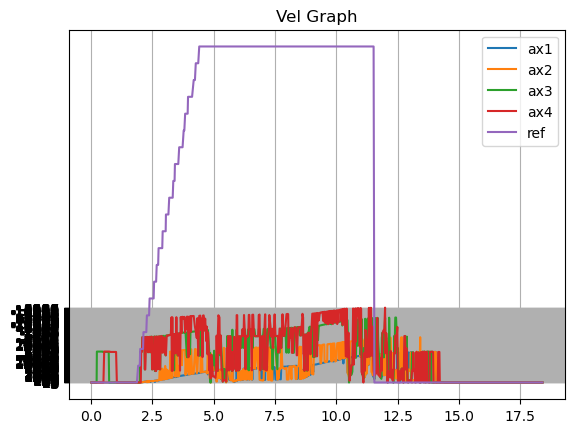

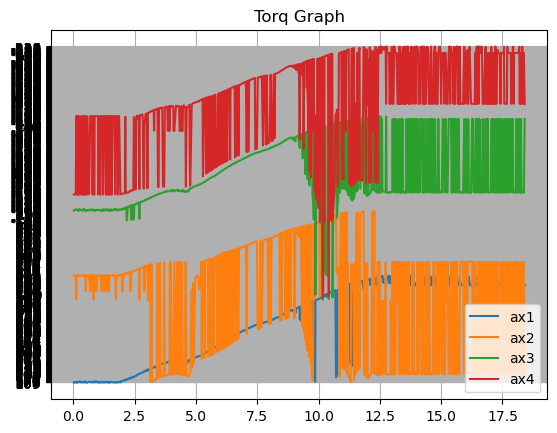

In [62]:
from interfaces.moby_client import MobyClient
from interfaces.ethercat_client import EtherCATClient
import time

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

ip = '192.168.214.20'
moby = MobyClient(ip)
ecat = EtherCATClient(ip)

rot_iwh = 1
# rot_iwh = 0 : rotation motor
# rot_iwh = 1 : inwheel motor

howlong = 800
# not accuracy unit

init_time = time.time()

now_time = []

whl_tx1 = []
whl_tx2 = []
whl_tx3 = []
whl_tx4 = []

whl_rx1 = []
whl_rx2 = []
whl_rx3 = []
whl_rx4 = []

for i in range(howlong):
    whl_tx1.append(ecat.get_servo_tx(0+rot_iwh))
    whl_tx2.append(ecat.get_servo_tx(2+rot_iwh))
    whl_tx3.append(ecat.get_servo_tx(4+rot_iwh))
    whl_tx4.append(ecat.get_servo_tx(6+rot_iwh))
    whl_rx1.append(ecat.get_servo_rx(0+rot_iwh))
    now_time.append(time.time() - init_time)
    time.sleep(0.005)

if (rot_iwh == 0):
    tx_whl1_pos= np.array(whl_tx1).T[2]
    tx_whl2_pos= np.array(whl_tx2).T[2]
    tx_whl3_pos= np.array(whl_tx3).T[2]
    tx_whl4_pos= np.array(whl_tx4).T[2]
    
    rx_whl1_pos = np.array(whl_rx1).T[2]

tx_whl1_vel = np.array(whl_tx1).T[3]
tx_whl2_vel = np.array(whl_tx2).T[3]
tx_whl3_vel = np.array(whl_tx3).T[3]
tx_whl4_vel = np.array(whl_tx4).T[3]

if (rot_iwh == 1):
    rx_whl1_vel = np.array(whl_rx1).T[3]

tx_whl1_trq = np.array(whl_tx1).T[4]
tx_whl2_trq = np.array(whl_tx2).T[4]
tx_whl3_trq = np.array(whl_tx3).T[4]
tx_whl4_trq = np.array(whl_tx4).T[4]

if (rot_iwh == 0):
    plt0 = plt
    plt0.plot(now_time, tx_whl1_pos, label="ax1")
    plt0.plot(now_time, tx_whl2_pos, label="ax2")
    plt0.plot(now_time, tx_whl3_pos, label="ax3")
    plt0.plot(now_time, tx_whl4_pos, label="ax4")

    plt0.plot(now_time, rx_whl1_pos, label="ref")

    plt0.title("Pos Graph")
    plt0.legend()
    plt0.grid(True)
    plt0.show()

plt1 = plt
plt1.plot(now_time, tx_whl1_vel, label="ax1")
plt1.plot(now_time, tx_whl2_vel, label="ax2")
plt1.plot(now_time, tx_whl3_vel, label="ax3")
plt1.plot(now_time, tx_whl4_vel, label="ax4")

if (rot_iwh == 1):
    plt1.plot(now_time, rx_whl1_vel, label="ref")

plt1.title("Vel Graph")
plt1.legend()
plt1.grid(True)
plt1.show()

plt2 = plt
plt2.plot(now_time, tx_whl1_trq, label="ax1")
plt2.plot(now_time, tx_whl2_trq, label="ax2")
plt2.plot(now_time, tx_whl3_trq, label="ax3")
plt2.plot(now_time, tx_whl4_trq, label="ax4")

plt2.title("Torq Graph")
plt2.legend()
plt2.grid(True)
plt2.show()



# def NumOp_GetDiff(uint32_t curr, uint32_t prev, uint32_t max):
#     diff = 0
#     half_max = max/2
#     diff = curr - prev
#     diff += half_max
    
#     if(diff < 0):
#         diff += max
#     diff %= max
#     diff -= half_max;return diff;}


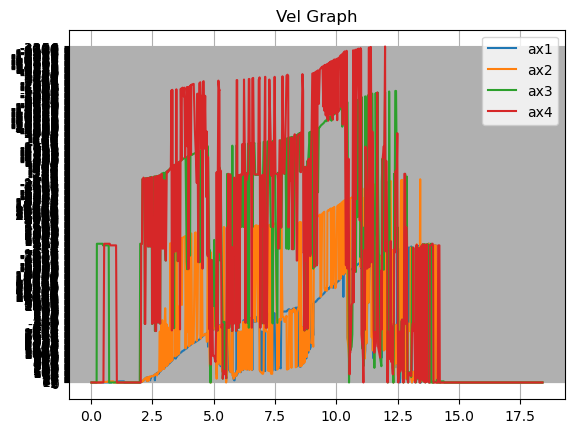

In [63]:
plt1 = plt
plt1.plot(now_time, tx_whl1_vel, label="ax1")
plt1.plot(now_time, tx_whl2_vel, label="ax2")
plt1.plot(now_time, tx_whl3_vel, label="ax3")
plt1.plot(now_time, tx_whl4_vel, label="ax4")

plt1.title("Vel Graph")
plt1.legend()
plt1.grid(True)
plt1.show()

In [ ]:

di_idx = {"fl":4, "fr":7, "bl":5, "br":6}

is_done = False
is_matched = False

err_cnt = 0
dif_angle = [0.0, 0.0, 0.0, 0.0]
wheel_state = {
  "last_steering_state": {"is_moving": False, "fl": 0.0, "fr": 0.0, "bl": 0.0, "br": 0.0},
  "rot_check_done": False
}

di_done = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
start_time = time.time()

while not is_done:
        
    try:
        cur_angle = moby.get_rotation_angle()
        while not is_matched:
            rot_dict = moby.get_rotation_angle()
            di_list = ecat.get_ioboard_tx()
            for i in range(len(di_done)):
                di_done[i] |= di_list[i]
            conv_list = [1 if x == 0 else 0 for x in di_done]

            moby.move_rotation_deg(fl=rot_dict["fl"]+conv_list[di_idx["fl"]], fr=rot_dict["fr"]+conv_list[di_idx["fr"]],
                                   bl=rot_dict["bl"]+conv_list[di_idx["bl"]], br=rot_dict["br"]+conv_list[di_idx["br"]])
            
            set_time = time.time() - start_time
            
            if (di_done[di_idx["fl"]] + di_done[di_idx["fr"]] + di_done[di_idx["bl"]] + di_done[di_idx["br"]]) >= 4:
                time.sleep(0.1)
                moby.stop_motion()
                time.sleep(0.1)
                # moby.set_zero_as_current()
                time.sleep(0.1)
                is_matched = True
                print("Reset Zero Angle Done!")
                break
                
            elif set_time > 120.0:
                print("Timeout 30 sec! Restart auto set")
                is_matched = True
                break
            
            time.sleep(0.1)
            
            print("set_deg:", rot_dict)
                print("di_list:", di_done)

        else:
            print("Steering Encoder Zero Count Checked")
            time.sleep(2)
            is_matched = True
            
        is_done = True
        
    except:
        time.sleep(2)
        print("No Data for Zero Auto Set")
        if err_cnt>10:
            is_done = True
        err_cnt+=1

wheel_state["rot_check_done"] = True
print(wheel_state)
save_json("/home/navifra/navigation-framework/navifra/wheel_state.json", wheel_state)